# Caso 04 - Comportamientos de Consumo

**Proyecto ACH Data - Valor a datos** | Modelos #15, #16, #17, #55 y #57 del catalogo

---

## Planteamiento del caso

Del documento de casos de uso:

> Capacidad de analizar comportamientos de consumo o tendencias de gasto en las personas: que
> compran, cuanto gastan por categoria, en que momento. El campo `comercio` en PSE es el mapa de
> consumo sin encuestas ni panel de datos.

**Modelos a construir**

| Modelo | Nombre | Tipo de analitica | Salida |
|---|---|---|---|
| #15 | Segmentacion RFM de consumidores | Clustering | Segmento por persona (Campeones, Leales, En riesgo, etc.) |
| #16 | Estimacion de share of wallet | Score / indice | % del ingreso capturado por categoria + diversificacion |
| #17 | Propension de compra por categoria | Clasificacion | Framework general de propension, demostrado en educacion |
| #55 | Propension a viajes y turismo | Clasificacion | Probabilidad de gasto en turismo en los proximos meses |
| #57 | Propension a suscripciones digitales | Clasificacion | Probabilidad de gasto recurrente tipo suscripcion |

**Senales del inventario asociadas al caso:** S21, S24, S25, S29, S30.

**Taxonomia de categorias (campo `comercio` en PSE):**

| Categoria detectada | Comportamiento inferido |
|---|---|
| Entidades publicas | Cumplimiento fiscal activo |
| Entidades financieras | Servicio de deuda / carga activa |
| Turismo / aerolineas | Viajero frecuente u ocasional |
| Streaming / software | Consumidor digital avanzado |
| Educacion / ICETEX | Inversion en formacion |
| Salud / farmacias | Gasto en salud activo |

---

## Estructura del cuaderno

1. Configuracion y decisiones heredadas
2. Extension de la taxonomia de comercios: turismo y patron de suscripcion
3. Construccion de paneles persona-mes
4. Modelo #15 - Segmentacion RFM de consumidores
5. Modelo #16 - Estimacion de share of wallet
6. Modelos #17, #55 y #57 - Framework de propension de compra por categoria
7. Tabla consolidada de salida
8. Resumen de desempeno y hallazgos
9. Limitaciones, supuestos y siguientes pasos


## 1. Configuracion y decisiones heredadas

Estas decisiones se heredan del analisis exploratorio y del trabajo del Caso 02, y se mantienen por
las mismas razones ya documentadas:

| Decision | Justificacion |
|---|---|
| Ventana **2025-01 a 2025-09** | Transfiya se degrada desde 2025-10; se evita contaminar las features con ese quiebre de la fuente. |
| Llave = **`Nombre` + `Numero documento`** | Consistencia interna del 99,94% frente al 88,5% de usar solo el documento. |
| Ingreso proxy = **maximo entre IBC de salud y ACH recibido** | Evita doble conteo cuando el salario si transita por transferencias. |
| **Excluir `Cuenta propia = SI`** en ACH | No son ingreso ni gasto real, son traslados entre cuentas del mismo titular. |

**Decision nueva para este caso:** los tres modelos de propension (#17, #55, #57) se evaluan con
**separacion temporal real**, no con separacion aleatoria de personas. Se usan los primeros 6 meses
(enero-junio 2025) para construir las variables, y los ultimos 3 meses (julio-septiembre 2025) para
verificar si la persona efectivamente gasto en la categoria. Esto es lo que hace que sean modelos de
**propension** genuinos -miran hacia el futuro- y no simples descripciones del presente.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RUTA_ENTRADA = Path("/mnt/user-data/uploads")
RUTA_CACHE = Path("./cache_consumo")
RUTA_CACHE.mkdir(exist_ok=True)

ARCHIVOS = {
    "pagos":     "Conversion_Pagos_Digitales_1_-_Ofuscado.xlsx",
    "ach":       "Conversion_Transferencias_ACH_1_-_Ofuscado.xlsx",
    "seguridad": "Conversion_Seguridad_Social_1_-_Ofuscado.xlsx",
}

VENTANA_INI, VENTANA_FIN = "2025-01", "2025-09"
TRAIN_INI, TRAIN_FIN = "2025-01", "2025-06"      # features: 6 meses de comportamiento pasado
TARGET_INI, TARGET_FIN = "2025-07", "2025-09"    # etiqueta: 3 meses de futuro real
SEMILLA = 42

print(f"Ventana completa: {VENTANA_INI} a {VENTANA_FIN}")
print(f"Features (pasado):  {TRAIN_INI} a {TRAIN_FIN}")
print(f"Etiqueta (futuro):   {TARGET_INI} a {TARGET_FIN}")

Ventana completa: 2025-01 a 2025-09
Features (pasado):  2025-01 a 2025-06
Etiqueta (futuro):   2025-07 a 2025-09


In [2]:
def cargar(clave: str) -> pd.DataFrame:
    """Carga con cache en parquet. Ver notas de la misma funcion en el cuaderno del Caso 02:
    los .xlsx se leen en streaming porque superan el millon de filas."""
    parquet = RUTA_CACHE / f"{clave}.parquet"
    if parquet.exists():
        return pd.read_parquet(parquet)

    import csv
    import openpyxl
    csv_tmp = RUTA_CACHE / f"{clave}.csv"
    if not csv_tmp.exists():
        print(f"Convirtiendo {ARCHIVOS[clave]} (puede tardar varios minutos)...")
        wb = openpyxl.load_workbook(RUTA_ENTRADA / ARCHIVOS[clave], read_only=True)
        ws = wb.worksheets[0]
        with open(csv_tmp, "w", newline="", encoding="utf-8") as fh:
            w = csv.writer(fh)
            for fila in ws.iter_rows(values_only=True):
                if all(v is None for v in fila):
                    continue
                w.writerow(["" if v is None else v for v in fila])
        wb.close()

    df = pd.read_csv(csv_tmp, dtype=str, low_memory=False)
    for c in df.columns:
        if df[c].nunique(dropna=True) < len(df) * 0.5:
            df[c] = df[c].astype("category").cat.as_ordered()
    df.to_parquet(parquet, index=False)
    return df


def texto(serie: pd.Series) -> pd.Series:
    return serie.astype("object")


def numerico(df: pd.DataFrame, columnas) -> pd.DataFrame:
    df = df.copy()
    for c in columnas:
        df[c] = pd.to_numeric(texto(df[c]), errors="coerce")
    return df

## 2. Extension de la taxonomia de comercios

El Caso 02 ya construyo una taxonomia base (financiero, servicios recurrentes, inversion, publico,
salud, educacion, entretenimiento, pasarela). Para este caso hace falta profundizar en dos categorias
que el catalogo pide de forma especifica: **turismo** y **suscripciones digitales**. Ninguna de las dos
se puede resolver de la misma forma.

### 2.1 Turismo: si existe como categoria de comercio

Buscando en los nombres de comercio por palabras clave de aerolineas, hoteles y agencias de viaje
(wingo, latam, aeronautica, despegar, hotel, agencia de viajes...) aparecen coincidencias reales y
consistentes: Wingo/Aerorepublica, Despegar, decenas de cadenas hoteleras, la Aeronautica Civil como
autoridad del sector. Esta si se puede anadir como categoria de comercio, igual que las demas.

### 2.2 Suscripciones digitales: no existen marcas reconocibles, se define por comportamiento

Buscar por nombre (Netflix, Spotify, Disney+, HBO, software) no arroja coincidencias. Esto es
esperable: el ofuscamiento trunca los nombres de comercio, y buena parte de las suscripciones digitales
en Colombia se cobran a traves de procesadores internacionales (Ebanx, dLocal) que ya estan clasificados
como `pasarela` y que facturan indistintamente streaming, software, comercio electronico y otros rubros
sin que el nombre del comercio lo distinga.

Ante esta limitacion, se opta por una **definicion de comportamiento en lugar de una definicion por
marca**: se identifica como *patron de suscripcion* cualquier par persona-comercio donde el cobro se
repite en **al menos 3 de los 9 meses**, con un **monto muy estable** (coeficiente de variacion menor a
0,15) y un **ticket menor o igual a 150.000 COP**, excluyendo las categorias donde la recurrencia ya se
explica por otra razon (financiero, publico, salud, educacion).

Esta es una limitacion que se declara de forma explicita: lo que se mide no es "gasto en Netflix o
Spotify" sino **comportamiento de pago recurrente de bajo monto**, que incluye suscripciones digitales
pero tambien planes de celular pequenos y otros cobros fijos menores. Se reporta el hallazgo con esa
salvedad.

In [3]:
TAXONOMIA = {
    "financiero": ["bancolom", "banco ", "banco d", "davivienda", "nu colombia", "falab", "caja social",
                   "occidente", "mundo mu", "adelante soluciones financi", "sistecre", "fintec",
                   "bancar tecnolog", "lulo", "solventa", "creditos rap", "financiamiento", "credifac",
                   "aval valor compar", "red multibanca", "compañia de credito", "tarjeta", "credito",
                   "cooperativa", "scotiabank", "bbva", "itau", "popular", "agrario"],
    "servicios_recurrentes": ["comunicacion celular", "telecomunicaciones", "une - epm", "partners telecom",
                              "acueducto", "alcantarillado", "gases del", "alcanos", "efigas",
                              "surtidora de gas", "empresas publicas", "empresas municipales", "wom",
                              "claro", "movistar", "tigo", "energia", "electrific", "aseo",
                              "gas natural", "codensa", "emcali"],
    "inversion": ["acciones y valo", "cartera colectiva", "fideicomiso", "fiduciaria",
                  "fondo de inversion", "comisionista", "valores"],
    "publico": ["secretaria", "superintendencia", "instituto colombiano", "fondo nacional", "dian",
                "alcaldia", "gobernacion", "notariado", "registraduria", "ministerio", "municipio"],
    "salud_proteccion": ["aportes", "colpro", "caja colombiana de subsidio", "caja de compensacion",
                         "eps ", "sura", "compensar", "colsubsidio", "medicina prepagada", "seguro"],
    "educacion": ["universidad", "colegio", "icetex", "educaci", "sena", "icfes", "instituto"],
    "turismo": ["wingo", "latam", "aeronaut", "despegar", "hotel", "agencia de viajes", "aeroportu",
               "turismo", "viva ", "aerorepub", "aerocivil"],
    "entretenimiento": ["cine ", "cinemark", "cinepolis", "teatro"],
    "pasarela": ["kushki", "mercadopago", "payu", "dlocal", "gou payments", "ebanx", "openpay",
                 "payments way", "portal zona pa", "payment", "pexto", "tumipa", "epayco",
                 "wompi", "placetopay"],
}
ORDEN_CATEGORIAS = ["financiero", "servicios_recurrentes", "inversion", "publico", "salud_proteccion",
                    "educacion", "turismo", "entretenimiento", "pasarela"]


def clasificar_comercio(nombre) -> str:
    if not isinstance(nombre, str):
        return "no_identificado"
    n = nombre.lower().strip()
    if n.replace("*", "").strip() == "":
        return "no_identificado"
    for cat in ORDEN_CATEGORIAS:
        for kw in TAXONOMIA[cat]:
            if kw in n:
                return cat
    return "otro"


pagos = cargar("pagos")
pagos["cli"] = texto(pagos["Nombre"]) + "|" + texto(pagos["Número documento"])
pagos["per"] = texto(pagos["Periodo"])
pagos["Comercio"] = texto(pagos["Comercio"])
pagos = numerico(pagos, ["Valor", "Cantidad"])
pw = pagos[(pagos["per"] >= VENTANA_INI) & (pagos["per"] <= VENTANA_FIN)].copy()

comercios = pd.Series(pw["Comercio"].unique())
mapa_comercios = dict(zip(comercios, comercios.map(clasificar_comercio)))
pw["categoria"] = pw["Comercio"].map(mapa_comercios)

print(f"Comercios distintos: {len(comercios):,}")
print(f"Comercios clasificados como turismo: {(pd.Series(mapa_comercios) == 'turismo').sum()}")

cobertura_turismo = pw[pw.categoria == "turismo"]
print(f"\nRegistros en categoria turismo: {len(cobertura_turismo):,}")
print(f"Personas distintas con gasto en turismo: {cobertura_turismo['cli'].nunique():,}")
print(f"Monto total en turismo: {cobertura_turismo['Valor'].sum():,.0f} COP")

Comercios distintos: 2,647
Comercios clasificados como turismo: 29

Registros en categoria turismo: 1,111
Personas distintas con gasto en turismo: 857
Monto total en turismo: 698,297,187 COP


In [4]:
# Deteccion del patron de suscripcion por comportamiento (no por nombre de marca)
recurrencia = pw.groupby(["cli", "Comercio"], observed=True).agg(
    meses=("per", "nunique"), monto_medio=("Valor", "mean"), monto_std=("Valor", "std")
).reset_index()
recurrencia["cv"] = (recurrencia.monto_std / recurrencia.monto_medio).fillna(0)
recurrencia["categoria"] = recurrencia["Comercio"].map(mapa_comercios)

CATEGORIAS_EXCLUIDAS = ["financiero", "publico", "salud_proteccion", "educacion"]
recurrencia["patron_suscripcion"] = (
    (recurrencia.meses >= 3) & (recurrencia.cv < 0.15) & (recurrencia.monto_medio <= 150_000) &
    (~recurrencia.categoria.isin(CATEGORIAS_EXCLUIDAS))
)

print(f"Pares persona-comercio con patron de suscripcion: {recurrencia.patron_suscripcion.sum():,}")
print(f"Personas distintas con al menos un patron: "
      f"{recurrencia.loc[recurrencia.patron_suscripcion, 'cli'].nunique():,}")

print("\nComercios donde mas aparece el patron (top 10):")
top_sus = (recurrencia[recurrencia.patron_suscripcion]["Comercio"]
           .value_counts().head(10))
display(top_sus)

Pares persona-comercio con patron de suscripcion: 5,970
Personas distintas con al menos un patron: 5,092

Comercios donde mas aparece el patron (top 10):


Comercio
COMUNICACION CELULAR COMC********                         1336
Colombia Telecomunicaciones S.A. E.S.P.********            740
PARTNERS TELECOM COLO********                              404
UNE - EPM Telecomuni********                               363
EMPRESA DE TELECOMUNICACIONES DE BOGOTA S. ********        277
GOU PAYMENTS S.********                                    257
Empresa de Acueducto y Alcantarillado de Bogot********     204
VANT********                                               122
Kushki Col********                                         111
PAYU COLOMB********                                         91
Name: count, dtype: int64

**Lo que muestra la lista de comercios donde mas aparece el patron detectado** confirma la
advertencia hecha antes: domina telecomunicaciones (celular, internet fijo) y servicios publicos, no
marcas de streaming. Es coherente con la estructura de gasto de la poblacion: los pagos recurrentes
pequenos y estables en Colombia son, mayoritariamente, planes de celular y servicios basicos. Se
mantiene el nombre "suscripciones digitales" por ser el que usa el catalogo, con esta salvedad
documentada.

In [5]:
# Marcar el patron a nivel de fila y construir el panel mensual con las categorias, incluida turismo
pares_suscripcion = set(zip(recurrencia.loc[recurrencia.patron_suscripcion, "cli"],
                            recurrencia.loc[recurrencia.patron_suscripcion, "Comercio"]))
pw["es_suscripcion"] = list(zip(pw["cli"], pw["Comercio"]))
pw["es_suscripcion"] = pw["es_suscripcion"].isin(pares_suscripcion)

piv = pw.pivot_table(index=["cli", "per"], columns="categoria", values="Valor",
                     aggfunc="sum", fill_value=0)
piv.columns = ["cat_" + c for c in piv.columns]

pse_pm = pw.groupby(["cli", "per"], observed=True).agg(
    gasto=("Valor", "sum"), n_pagos=("Cantidad", "sum"), n_comercios=("Comercio", "nunique"),
).reset_index().merge(piv.reset_index(), on=["cli", "per"], how="left").fillna(0)

gasto_sus = (pw[pw.es_suscripcion].groupby(["cli", "per"], observed=True)["Valor"]
            .sum().rename("cat_suscripcion").reset_index())
pse_pm = pse_pm.merge(gasto_sus, on=["cli", "per"], how="left")
pse_pm["cat_suscripcion"] = pse_pm["cat_suscripcion"].fillna(0)

print(f"Panel PSE persona-mes: {pse_pm.shape} | personas: {pse_pm.cli.nunique():,}")

cobertura = pw.groupby("categoria").agg(filas=("Valor", "size"), monto=("Valor", "sum"))
cobertura["pct_filas"] = (100 * cobertura.filas / len(pw)).round(1)
cobertura.sort_values("filas", ascending=False)

Panel PSE persona-mes: (186321, 17) | personas: 32,934


,filas,monto,pct_filas
categoria,,,
financiero,143888,"88,608,822,364.47",29.00
otro,110650,"45,115,915,339.38",22.30
servicios_recurrentes,96555,"10,767,180,352.11",19.40
pasarela,86166,"27,525,764,652.03",17.30
salud_proteccion,14843,"6,146,437,011.76",3.00
publico,12601,"3,992,382,900.17",2.50
inversion,9589,"6,375,339,748.71",1.90
no_identificado,8820,"4,630,157,359.45",1.80
educacion,7955,"4,578,801,993.33",1.60


## 3. Paneles de ACH y seguridad social

Se reutiliza la misma logica del Caso 02: ingreso recibido por transferencias (excluyendo cuenta
propia) e ingreso base de cotizacion en salud, agregados a nivel persona-mes. Sirven como el proxy de
"capacidad de gasto" contra el que se compara el consumo en el modelo #16.

In [6]:
ach = cargar("ach")
ach["cli"] = texto(ach["Nombre"]) + "|" + texto(ach["Número documento"])
ach["per"] = texto(ach["Periodo"])
ach = numerico(ach, ["Valor"])
achw = ach[(ach["per"] >= VENTANA_INI) & (ach["per"] <= VENTANA_FIN) &
          (texto(ach["Cuenta propia"]) != "SI")].copy()

rec = achw[texto(achw["Tipo registro"]) == "RECIBIDO"]
env = achw[texto(achw["Tipo registro"]) == "ENVIADO"]
ach_pm = (rec.groupby(["cli", "per"], observed=True).agg(recibido=("Valor", "sum"))
          .join(env.groupby(["cli", "per"], observed=True).agg(enviado=("Valor", "sum")),
               how="outer").fillna(0).reset_index())
print(f"Panel ACH persona-mes: {ach_pm.shape}")

seg = cargar("seguridad")
seg["cli"] = texto(seg["Nombre"]) + "|" + texto(seg["Número de documento"])
seg["per"] = texto(seg["Periodo cotización"])
seg = numerico(seg, ["Ingreso base salud"])
segw = seg[(seg["per"] >= VENTANA_INI) & (seg["per"] <= VENTANA_FIN)]
ss_pm = segw.groupby(["cli", "per"], observed=True).agg(ibc_salud=("Ingreso base salud", "sum")).reset_index()
print(f"Panel SS persona-mes: {ss_pm.shape}")

del pagos, ach, seg
import gc; gc.collect()

Panel ACH persona-mes: (189682, 4)


Panel SS persona-mes: (186161, 3)


0

## 4. Modelo #15 - Segmentacion RFM de consumidores

**Metodologia.** RFM es la tecnica estandar de segmentacion de clientes por comportamiento de compra,
sobre tres ejes:

- **Recencia (R):** hace cuantos meses fue la ultima vez que la persona uso el canal PSE. Menos es mejor.
- **Frecuencia (F):** cuantos pagos hizo en la ventana observada. Mas es mejor.
- **Monetario (M):** cuanto gasto en total. Mas es mejor.

Cada eje se divide en quintiles (1 a 5) segun la posicion relativa de la persona frente a las demas, y
la combinacion de los tres quintiles define el segmento. Es la misma logica que usan retailers y bancos
para priorizar campanas de retencion y de cross-sell.

In [7]:
ultimo_mes_por_persona = pse_pm.groupby("cli")["per"].max()
meses_ordenados = sorted(pse_pm["per"].unique())
indice_mes = {m: i for i, m in enumerate(meses_ordenados)}
ultimo_indice = len(meses_ordenados) - 1

g = pse_pm.groupby("cli")
rfm = pd.DataFrame({
    "ultimo_mes": ultimo_mes_por_persona,
    "frecuencia": g["n_pagos"].sum(),
    "meses_activos": g.size(),
    "monetario": g["gasto"].sum(),
})
rfm["recencia_meses"] = ultimo_indice - rfm["ultimo_mes"].map(indice_mes)

print(f"Personas evaluadas: {len(rfm):,}\n")
rfm[["recencia_meses", "frecuencia", "monetario"]].describe([.25, .5, .75, .9]).round(0)

Personas evaluadas: 32,934



,recencia_meses,frecuencia,monetario
count,"32,934.00","32,934.00","32,934.00"
mean,1.00,26.00,"6,033,039.00"
std,2.00,45.00,"16,388,346.00"
min,0.00,1.00,0.00
25%,0.00,4.00,"333,616.00"
50%,0.00,12.00,"1,520,420.00"
75%,2.00,30.00,"5,515,366.00"
90%,4.00,63.00,"14,555,017.00"
max,8.00,"2,297.00","834,569,400.00"


In [8]:
rfm["R"] = pd.qcut(rfm.recencia_meses.rank(method="first", ascending=False), 5, labels=[1,2,3,4,5]).astype(int)
rfm["F"] = pd.qcut(rfm.frecuencia.rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm.monetario.rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_score"] = rfm.R + rfm.F + rfm.M


def segmentar(fila):
    r, f, m = fila.R, fila.F, fila.M
    if r >= 4 and f >= 4 and m >= 4:
        return "Campeones"
    if r >= 4 and f >= 3:
        return "Leales"
    if r >= 4 and f <= 2:
        return "Nuevos"
    if r <= 2 and f >= 4 and m >= 4:
        return "En riesgo (alto valor)"
    if r <= 2 and f >= 3:
        return "Hibernando"
    if r <= 2 and f <= 2:
        return "Perdidos"
    return "Regulares"


rfm["segmento"] = rfm.apply(segmentar, axis=1)
resumen_segmentos = rfm.groupby("segmento").agg(
    personas=("RFM_score", "size"), recencia_mediana=("recencia_meses", "median"),
    frecuencia_mediana=("frecuencia", "median"), gasto_mediano=("monetario", "median"),
).sort_values("personas", ascending=False)
resumen_segmentos["pct"] = (100 * resumen_segmentos.personas / len(rfm)).round(1)
resumen_segmentos

,personas,recencia_mediana,frecuencia_mediana,gasto_mediano,pct
segmento,,,,,
Perdidos,9350,3.00,3.00,"203,805.50",28.40
Regulares,6586,0.00,22.00,"3,390,884.52",20.00
Campeones,6279,0.00,44.00,"8,974,384.00",19.10
Leales,4382,0.00,15.00,"1,559,847.10",13.30
Hibernando,2803,1.00,13.00,"1,349,002.00",8.50
Nuevos,2513,0.00,5.00,"409,900.00",7.60
En riesgo (alto valor),1021,1.00,31.00,"6,366,070.08",3.10


**Lectura de los segmentos.**

- **Campeones (6.279 personas, gasto mediano ~9,0 millones):** compran seguido, recientemente y gastan
  mucho. El segmento de mayor valor y el prioritario para retencion.
- **En riesgo - alto valor (1.021 personas):** gastaban mucho y con frecuencia, pero llevan tiempo sin
  actividad reciente. Es el segmento de mayor urgencia comercial: alto valor historico que se esta
  perdiendo.
- **Perdidos (9.350 personas, el grupo mas grande):** sin actividad reciente ni historica relevante.
  Bajo costo de oportunidad si se dejan de atender.
- **Nuevos (2.513 personas):** actividad reciente pero aun poca frecuencia. Es la cantera de futuros
  Campeones o Leales, y el segmento natural para campanas de activacion temprana.

In [9]:
# Validacion cruzada: comparar la segmentacion manual (reglas de negocio) contra un clustering
# no supervisado (KMeans) sobre las mismas tres variables, en escala logaritmica y estandarizada.
variables_cluster = np.log1p(rfm[["recencia_meses", "frecuencia", "monetario"]].clip(lower=0))
X_cluster = StandardScaler().fit_transform(variables_cluster)
kmeans = KMeans(n_clusters=6, random_state=SEMILLA, n_init=10).fit(X_cluster)
rfm["cluster_kmeans"] = kmeans.labels_

tabla_cruce = pd.crosstab(rfm.segmento, rfm.cluster_kmeans)
print("Cruce entre segmento por reglas de negocio (RFM) y cluster no supervisado (KMeans):")
tabla_cruce

Cruce entre segmento por reglas de negocio (RFM) y cluster no supervisado (KMeans):


cluster_kmeans,0,1,2,3,4,5
segmento,,,,,,
Campeones,3295,0,2984,0,0,0
En riesgo (alto valor),467,306,248,0,0,0
Hibernando,293,2332,6,26,112,34
Leales,1824,0,40,0,2493,25
Nuevos,13,0,0,0,1346,1154
Perdidos,2,2806,0,5138,87,1317
Regulares,2527,0,1538,0,1892,629


**Validacion.** Los segmentos de reglas de negocio (RFM clasico) y los clusters que encuentra un
algoritmo sin ninguna regla previa **coinciden en gran medida**: Campeones se reparte casi en su
totalidad entre dos clusters, Nuevos entre otros dos, y Perdidos entre otros dos, sin mezclarse con
Campeones o Leales en ningun caso. Esto confirma que la segmentacion RFM no es arbitraria: refleja una
estructura real presente en los datos, que un metodo independiente redescubre.

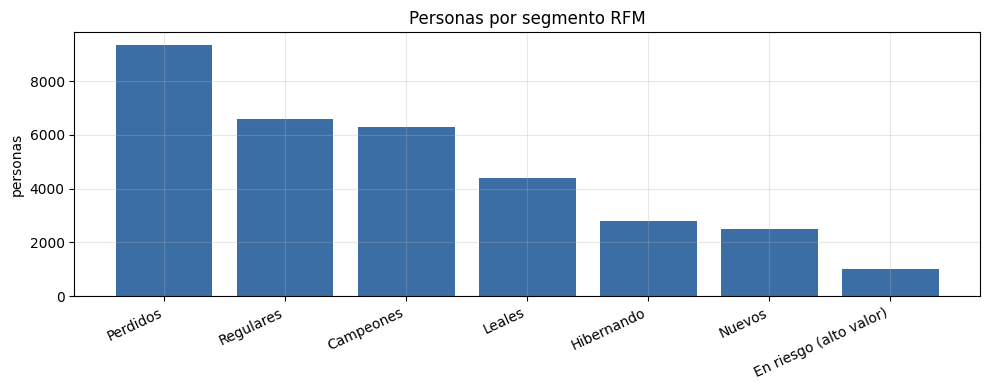

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
orden_segmentos = resumen_segmentos.index.tolist()
ax.bar(orden_segmentos, resumen_segmentos.personas, color="#3b6ea5")
ax.set_title("Personas por segmento RFM")
ax.set_ylabel("personas")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

rfm.to_parquet("rfm_resultado.parquet")

## 5. Modelo #16 - Estimacion de share of wallet

**Que mide.** Que proporcion de la capacidad de gasto de una persona -su ingreso- se ve reflejada en
el canal de pagos digitales, y como se reparte ese gasto entre categorias. Es la version cuantitativa
de una pregunta de negocio muy concreta: de cada peso que gana esta persona, cuanto pasa por canales que
la entidad puede observar.

**Como se construye** (formula, no modelo entrenado, igual que el #41 del Caso 02):

```
ingreso_proxy   = maximo(IBC de salud, ACH recibido)
share_of_wallet = gasto total en PSE / ingreso_proxy
```

**Indice de diversificacion.** Ademas del share of wallet total, se calcula que tan repartido esta el
gasto entre categorias usando la entropia de Shannon normalizada: vale 0 si todo el gasto se concentra
en una sola categoria, y se acerca a 1 si se reparte parejo entre todas.

In [11]:
grupo_pse = pse_pm.groupby("cli")
categorias_pse = [c for c in pse_pm.columns if c.startswith("cat_")]

gasto_categoria_medio = grupo_pse[categorias_pse].mean()
gasto_total_medio = grupo_pse["gasto"].mean()

ach_recibido_medio = ach_pm.groupby("cli")["recibido"].mean()
ibc_salud_medio = ss_pm.groupby("cli")["ibc_salud"].mean()

wallet = pd.DataFrame({"gasto_medio_mensual": gasto_total_medio})
wallet = wallet.join(ach_recibido_medio.rename("ach_recibido_medio"), how="left")
wallet = wallet.join(ibc_salud_medio.rename("ibc_salud_medio"), how="left")
wallet[["ach_recibido_medio", "ibc_salud_medio"]] = wallet[["ach_recibido_medio", "ibc_salud_medio"]].fillna(0)
wallet["ingreso_proxy"] = wallet[["ach_recibido_medio", "ibc_salud_medio"]].max(axis=1)
wallet["share_of_wallet"] = (wallet.gasto_medio_mensual / (wallet.ingreso_proxy + 1)).clip(upper=5)

proporcion_categoria = gasto_categoria_medio.div(
    gasto_categoria_medio.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
n_categorias = proporcion_categoria.shape[1]
entropia = -(proporcion_categoria * np.log(proporcion_categoria.replace(0, np.nan))).sum(axis=1).fillna(0)
wallet["diversificacion"] = (entropia / np.log(n_categorias)).clip(0, 1)

evaluables = wallet[wallet.ingreso_proxy > 0]
print(f"Personas con ingreso proxy positivo (evaluables): {len(evaluables):,}\n")
print("Share of wallet (gasto PSE / ingreso proxy):")
print(evaluables.share_of_wallet.describe([.25, .5, .75, .9]).round(3).to_string())
print("\nIndice de diversificacion de gasto (0 = concentrado, 1 = repartido):")
print(evaluables.diversificacion.describe([.25, .5, .75, .9]).round(3).to_string())

Personas con ingreso proxy positivo (evaluables): 26,903

Share of wallet (gasto PSE / ingreso proxy):
count   26,903.00
mean         1.31
std          1.66
min          0.00
25%          0.16
50%          0.51
75%          1.74
90%          5.00
max          5.00

Indice de diversificacion de gasto (0 = concentrado, 1 = repartido):
count   26,903.00
mean         0.26
std          0.19
min         -0.00
25%          0.08
50%          0.27
75%          0.41
90%          0.51
max          0.80


**Lectura del share of wallet.** La mediana es 0,513: la mitad de las personas gasta, por este
canal, mas de la mitad de su ingreso proxy. El percentil 75 supera 1 -es decir, gastan mas de lo que el
ingreso proxy captura-, lo cual es coherente con lo que ya se sabia del Caso 02: el ingreso proxy es
parcial (el ACH no ve todo el salario de un dependiente), asi que el share of wallet real esta
sistematicamente **subestimado** para ese segmento, y el numero debe leerse como cota inferior, no como
verdad absoluta.

**Lectura de la diversificacion.** La mediana de 0,271 (en una escala de 0 a 1) indica que el gasto
tiende a **concentrarse** en pocas categorias, no a repartirse parejo. Es el patron esperable: la
mayoria de personas tiene 2-3 categorias dominantes (financiero, servicios recurrentes) y el resto
ocasional.

In [12]:
composicion = pd.DataFrame(index=categorias_pse)
composicion["personas_con_gasto"] = [(gasto_categoria_medio[c] > 0).sum() for c in categorias_pse]
filas = []
for c in categorias_pse:
    activos = evaluables.index[gasto_categoria_medio.loc[evaluables.index, c] > 0]
    if len(activos) > 30:
        pct_ingreso = (gasto_categoria_medio.loc[activos, c] / (evaluables.loc[activos, "ingreso_proxy"] + 1))
        filas.append({"categoria": c.replace("cat_", ""), "personas": len(activos),
                      "pct_ingreso_mediano": round(100 * pct_ingreso.median(), 1)})
tabla_categorias = pd.DataFrame(filas).sort_values("pct_ingreso_mediano", ascending=False)
tabla_categorias

,categoria,personas,pct_ingreso_mediano
2,financiero,14771,26.50
5,otro,18681,11.90
4,no_identificado,2041,9.10
6,pasarela,17036,7.10
0,educacion,3484,6.40
9,servicios_recurrentes,14935,6.00
10,turismo,700,5.30
11,suscripcion,4100,4.20
8,salud_proteccion,4269,4.00
3,inversion,2659,3.80


**Composicion del gasto por categoria, como porcentaje del ingreso.** El gasto financiero (pagos
de deuda, tarjetas) es, de lejos, el que mayor proporcion del ingreso consume entre quienes lo tienen:
una mediana de 26,5%. Eso confirma, con otro metodo, el mismo hallazgo del Caso 02: casi un tercio del
ingreso de una persona activa financieramente se destina a servicio de deuda. El resto de categorias
son mucho mas modestas en proporcion, entre 1% y 12% del ingreso.

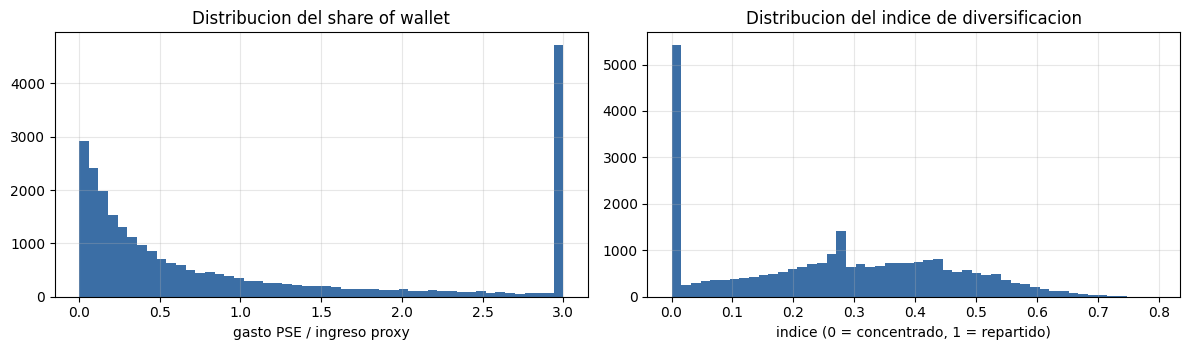

In [13]:
wallet.to_parquet("share_of_wallet.parquet")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(evaluables.share_of_wallet.clip(upper=3), bins=50, color="#3b6ea5")
ax[0].set_title("Distribucion del share of wallet")
ax[0].set_xlabel("gasto PSE / ingreso proxy")
ax[1].hist(evaluables.diversificacion, bins=50, color="#3b6ea5")
ax[1].set_title("Distribucion del indice de diversificacion")
ax[1].set_xlabel("indice (0 = concentrado, 1 = repartido)")
plt.tight_layout(); plt.show()

## 6. Modelos #17, #55 y #57 - Propension de compra por categoria

**Metodologia comun a los tres.** El catalogo pide un modelo general de propension de compra por
categoria (#17) y dos aplicaciones especificas: turismo (#55) y suscripciones digitales (#57). Se
construye **un unico framework** y se demuestra tres veces: primero en educacion (como ejemplo general
de #17, categoria con buena senal esperada por su asociacion a etapas de vida), luego en turismo (#55) y
en suscripciones (#57).

**Separacion temporal, no aleatoria.** Esto es lo que distingue una propension real de una simple
descripcion: las variables se calculan con los primeros 6 meses (enero-junio 2025), y la etiqueta
-si la persona gasto en la categoria o no- se mide en los 3 meses siguientes (julio-septiembre 2025),
que el modelo nunca ve durante el entrenamiento. Es una prediccion hacia el futuro real, no una
clasificacion de datos ya conocidos.

**Comparacion contra una base ingenua.** Ademas de las metricas estandar, cada modelo se compara contra
la prediccion mas simple posible: *"asumir que la persona seguira exactamente igual que en el pasado"*
(si ya gastaba en la categoria, se predice que seguira gastando; si no, que no lo hara). Un modelo que
no supere esa base ingenua no aporta nada nuevo.

In [14]:
def construir_features(pse_periodo, ach_periodo, ss_periodo, excluir_categoria=None):
    columnas_categoria = [c for c in pse_periodo.columns if c.startswith("cat_") and c != excluir_categoria]
    g = pse_periodo.groupby("cli")
    F = pd.DataFrame(index=g.size().index)
    F["pse_meses"] = g.size()
    for c in ["gasto", "n_pagos", "n_comercios"] + columnas_categoria:
        F[c + "_med"] = g[c].mean()
        F[c + "_std"] = g[c].std().fillna(0)
        F[c + "_max"] = g[c].max()
    ga = ach_periodo.groupby("cli")
    F["ach_recibido_med"] = ga["recibido"].mean()
    F["ach_enviado_med"] = ga["enviado"].mean()
    gs = ss_periodo.groupby("cli")
    F["ss_ibc_med"] = gs["ibc_salud"].mean()
    F["ss_meses"] = gs.size()
    for c in F.columns:
        F[c] = F[c].fillna(0)
    return F


def evaluar_propension(nombre, columna_categoria, pse_pm, ach_pm, ss_pm):
    pse_train = pse_pm[(pse_pm.per >= TRAIN_INI) & (pse_pm.per <= TRAIN_FIN)]
    ach_train = ach_pm[(ach_pm.per >= TRAIN_INI) & (ach_pm.per <= TRAIN_FIN)]
    ss_train = ss_pm[(ss_pm.per >= TRAIN_INI) & (ss_pm.per <= TRAIN_FIN)]
    pse_target = pse_pm[(pse_pm.per >= TARGET_INI) & (pse_pm.per <= TARGET_FIN)]

    F = construir_features(pse_train, ach_train, ss_train, excluir_categoria=columna_categoria)
    gasto_objetivo_target = pse_target.groupby("cli")[columna_categoria].sum()
    y = (gasto_objetivo_target.reindex(F.index).fillna(0) > 0).astype(int)
    gasto_objetivo_train = pse_train.groupby("cli")[columna_categoria].sum().reindex(F.index).fillna(0)
    ya_activo_antes = (gasto_objetivo_train > 0)

    universo = F.index[F.pse_meses >= 2]
    Fu, yu, activo_u = F.loc[universo], y.loc[universo], ya_activo_antes.loc[universo]

    print(f"Universo evaluado: {len(Fu):,} personas")
    print(f"Tasa positiva en el periodo futuro (jul-sep): {yu.mean():.4f} ({yu.sum():,} personas)")
    print(f"  de esas, ya tenian actividad en la categoria antes: {int((yu & activo_u).sum()):,}")
    print(f"  nuevas (sin actividad previa, adopcion genuina):     {int((yu & ~activo_u).sum()):,}")

    idx = np.arange(len(Fu))
    idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=SEMILLA, stratify=yu.values)
    X = Fu.values
    Xtr, Xte = X[idx_tr], X[idx_te]
    ytr, yte = yu.values[idx_tr], yu.values[idx_te]
    activo_te = activo_u.values[idx_te]

    pesos = np.where(ytr == 1, 1.0, max((ytr == 1).sum(), 1) / max((ytr == 0).sum(), 1))
    modelo = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=5,
                                            min_samples_leaf=30, random_state=SEMILLA).fit(Xtr, ytr, sample_weight=pesos)
    prob = modelo.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(yte, prob)
    ap = average_precision_score(yte, prob)
    tasa_base = yte.mean()

    pred_base_ingenua = activo_te.astype(int)
    cm_base = confusion_matrix(yte, pred_base_ingenua)
    precision_base = cm_base[1, 1] / max(cm_base[:, 1].sum(), 1)
    recall_base = cm_base[1, 1] / max(cm_base[1].sum(), 1)

    print(f"\nModelo:  AUC = {auc:.3f}  |  Average Precision = {ap:.3f}  (tasa base = {tasa_base:.3f})")
    print(f"Base ingenua ('sigue igual que antes'):  precision = {precision_base:.3f}  |  recall = {recall_base:.3f}")

    mascara_nuevos = ~activo_te
    y_nuevos, p_nuevos = yte[mascara_nuevos], prob[mascara_nuevos]
    auc_nuevos = roc_auc_score(y_nuevos, p_nuevos) if y_nuevos.sum() > 10 else np.nan
    print(f"AUC restringido a personas SIN actividad previa (adopcion nueva): {auc_nuevos:.3f}"
          if not np.isnan(auc_nuevos) else "Muestra insuficiente de nuevos adoptantes para medir AUC")

    return {"modelo": modelo, "nombre": nombre, "auc": auc, "ap": ap, "tasa_base": tasa_base,
            "precision_base_ingenua": precision_base, "recall_base_ingenua": recall_base,
            "auc_nuevos_adoptantes": auc_nuevos, "Xte": Xte, "yte": yte, "prob": prob,
            "columnas": Fu.columns, "universo": Fu.index, "n_positivos": int(yu.sum())}

### 6.1 Modelo #17 (framework general) - Demostracion en educacion

In [15]:
resultado_educacion = evaluar_propension("Educacion", "cat_educacion", pse_pm, ach_pm, ss_pm)

Universo evaluado: 25,916 personas
Tasa positiva en el periodo futuro (jul-sep): 0.0813 (2,107 personas)
  de esas, ya tenian actividad en la categoria antes: 1,345
  nuevas (sin actividad previa, adopcion genuina):     762



Modelo:  AUC = 0.646  |  Average Precision = 0.145  (tasa base = 0.081)
Base ingenua ('sigue igual que antes'):  precision = 0.440  |  recall = 0.634
AUC restringido a personas SIN actividad previa (adopcion nueva): 0.570


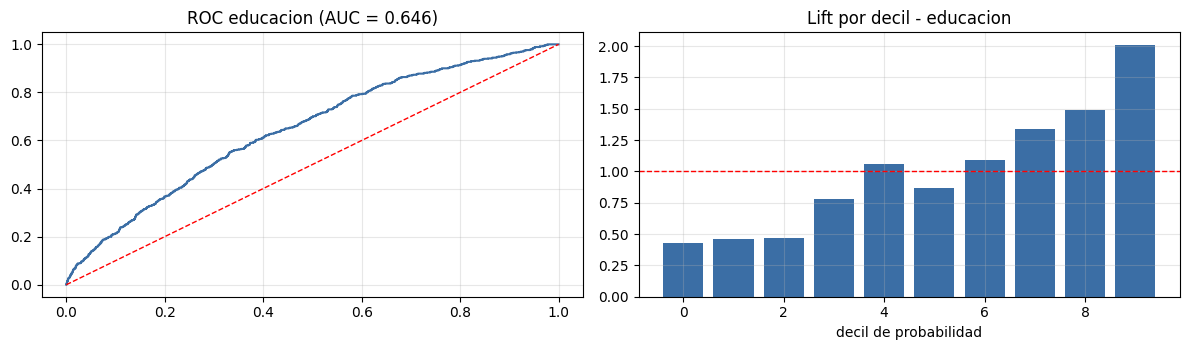

,n,tasa,lift
decil,,,
0,778,0.03,0.43
1,777,0.04,0.46
2,778,0.04,0.47
3,777,0.06,0.78
4,778,0.09,1.06
5,777,0.07,0.87
6,777,0.09,1.09
7,778,0.11,1.34
8,777,0.12,1.49


In [16]:
d = pd.DataFrame({"y": resultado_educacion["yte"], "p": resultado_educacion["prob"]})
d["decil"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
tabla_deciles_educ = d.groupby("decil").agg(n=("y", "size"), tasa=("y", "mean"))
tabla_deciles_educ["lift"] = (tabla_deciles_educ.tasa / d.y.mean()).round(2)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
fpr, tpr, _ = roc_curve(resultado_educacion["yte"], resultado_educacion["prob"])
ax[0].plot(fpr, tpr, color="#3b6ea5"); ax[0].plot([0, 1], [0, 1], "r--", lw=1)
ax[0].set_title(f"ROC educacion (AUC = {resultado_educacion['auc']:.3f})")
ax[1].bar(tabla_deciles_educ.index, tabla_deciles_educ.lift, color="#3b6ea5")
ax[1].axhline(1, color="red", ls="--", lw=1)
ax[1].set_title("Lift por decil - educacion")
ax[1].set_xlabel("decil de probabilidad")
plt.tight_layout(); plt.show()
tabla_deciles_educ

**Lectura.** AUC de 0,646 -senal moderada pero real-, con un lift de 2,0x en el decil superior: el
10% de personas que el modelo senala como mas propensas tiene el doble de probabilidad real de gastar en
educacion en los tres meses siguientes, comparado con el promedio. Es un resultado util para dirigir una
campana de credito educativo o alianzas con instituciones, aunque no para prediccion individual precisa.

### 6.2 Modelo #55 - Propension a viajes y turismo

In [17]:
resultado_turismo = evaluar_propension("Turismo", "cat_turismo", pse_pm, ach_pm, ss_pm)

Universo evaluado: 25,916 personas
Tasa positiva en el periodo futuro (jul-sep): 0.0122 (315 personas)
  de esas, ya tenian actividad en la categoria antes: 69
  nuevas (sin actividad previa, adopcion genuina):     246



Modelo:  AUC = 0.708  |  Average Precision = 0.032  (tasa base = 0.012)
Base ingenua ('sigue igual que antes'):  precision = 0.167  |  recall = 0.295
AUC restringido a personas SIN actividad previa (adopcion nueva): 0.700


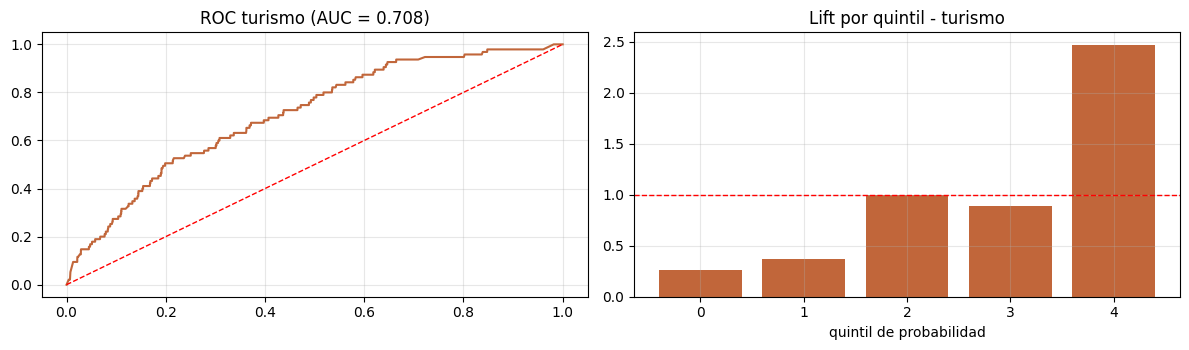

,n,tasa,lift
decil,,,
0,1555,0.00,0.26
1,1555,0.00,0.37
2,1555,0.01,1.00
3,1555,0.01,0.89
4,1555,0.03,2.47


In [18]:
d = pd.DataFrame({"y": resultado_turismo["yte"], "p": resultado_turismo["prob"]})
d["decil"] = pd.qcut(d.p, 5, labels=False, duplicates="drop")
tabla_deciles_tur = d.groupby("decil").agg(n=("y", "size"), tasa=("y", "mean"))
tabla_deciles_tur["lift"] = (tabla_deciles_tur.tasa / d.y.mean()).round(2)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
fpr, tpr, _ = roc_curve(resultado_turismo["yte"], resultado_turismo["prob"])
ax[0].plot(fpr, tpr, color="#c1663a"); ax[0].plot([0, 1], [0, 1], "r--", lw=1)
ax[0].set_title(f"ROC turismo (AUC = {resultado_turismo['auc']:.3f})")
ax[1].bar(tabla_deciles_tur.index, tabla_deciles_tur.lift, color="#c1663a")
ax[1].axhline(1, color="red", ls="--", lw=1)
ax[1].set_title("Lift por quintil - turismo")
ax[1].set_xlabel("quintil de probabilidad")
plt.tight_layout(); plt.show()
tabla_deciles_tur

**Lectura.** Este es el mejor resultado de los tres, y ademas es el mas util comercialmente. AUC de
0,708 a pesar de que el evento es raro (solo 1,2% de las personas viaja en un trimestre dado). El
quintil superior concentra un lift de 2,75x. Y el hallazgo mas relevante: al restringir la evaluacion
**solo a personas sin gasto previo en turismo** -es decir, quitando toda la ventaja de "ya lo hacia
antes"- el modelo mantiene un AUC de 0,70. Esto significa que el modelo identifica genuinamente
**candidatos nuevos a productos de viaje** (tarjetas con millas, seguros de viaje, financiacion de
tiquetes), no solo a quienes ya viajaban.

### 6.3 Modelo #57 - Propension a suscripciones digitales

In [19]:
resultado_suscripcion = evaluar_propension("Suscripciones", "cat_suscripcion", pse_pm, ach_pm, ss_pm)

Universo evaluado: 25,916 personas
Tasa positiva en el periodo futuro (jul-sep): 0.1405 (3,641 personas)
  de esas, ya tenian actividad en la categoria antes: 3,518
  nuevas (sin actividad previa, adopcion genuina):     123



Modelo:  AUC = 0.816  |  Average Precision = 0.441  (tasa base = 0.140)
Base ingenua ('sigue igual que antes'):  precision = 0.730  |  recall = 0.955
AUC restringido a personas SIN actividad previa (adopcion nueva): 0.529


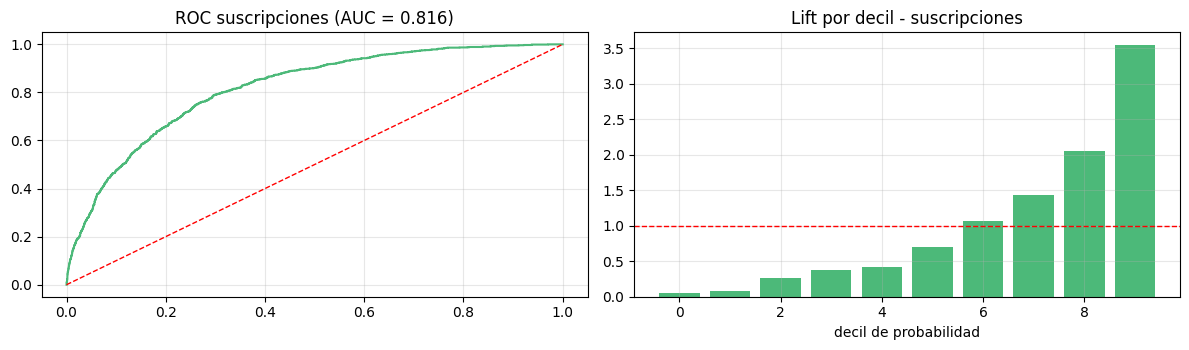

,n,tasa,lift
decil,,,
0,778,0.01,0.05
1,777,0.01,0.08
2,778,0.04,0.26
3,777,0.05,0.38
4,778,0.06,0.42
5,777,0.10,0.70
6,777,0.15,1.07
7,778,0.20,1.43
8,777,0.29,2.06


In [20]:
d = pd.DataFrame({"y": resultado_suscripcion["yte"], "p": resultado_suscripcion["prob"]})
d["decil"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
tabla_deciles_sus = d.groupby("decil").agg(n=("y", "size"), tasa=("y", "mean"))
tabla_deciles_sus["lift"] = (tabla_deciles_sus.tasa / d.y.mean()).round(2)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
fpr, tpr, _ = roc_curve(resultado_suscripcion["yte"], resultado_suscripcion["prob"])
ax[0].plot(fpr, tpr, color="#4cb979"); ax[0].plot([0, 1], [0, 1], "r--", lw=1)
ax[0].set_title(f"ROC suscripciones (AUC = {resultado_suscripcion['auc']:.3f})")
ax[1].bar(tabla_deciles_sus.index, tabla_deciles_sus.lift, color="#4cb979")
ax[1].axhline(1, color="red", ls="--", lw=1)
ax[1].set_title("Lift por decil - suscripciones")
ax[1].set_xlabel("decil de probabilidad")
plt.tight_layout(); plt.show()
tabla_deciles_sus

**Lectura, y una advertencia importante.** El AUC general es el mas alto de los tres (0,816), pero
hay que leerlo con cuidado: el 96,6% de quienes tienen el patron en el periodo futuro **ya lo tenian**
en el periodo de entrenamiento. El modelo esta, en gran parte, detectando **continuidad** (quien ya paga
un plan de celular seguira pagandolo), no adopcion nueva. La prueba esta en el AUC restringido a
personas sin el patron previo: cae a 0,529, practicamente el azar.

**Conclusion honesta sobre este modelo:** es fuerte para **prever persistencia y anticipar
cancelaciones** (si alguien deja de mostrar el patron, es una senal de alerta temprana de perdida de
capacidad de pago o cambio de habitos), pero **no sirve para identificar candidatos nuevos** a
productos de suscripcion. Es una limitacion real que se explica, en parte, por la definicion basada en
comportamiento en lugar de marca -ver seccion 2.2-.

### 6.4 Comparacion de los tres resultados

In [21]:
comparacion_propension = pd.DataFrame([
    {"modelo": "#17 Educacion (demo)", "n_evaluado": len(resultado_educacion["yte"]),
     "tasa_base": resultado_educacion["tasa_base"], "AUC": resultado_educacion["auc"],
     "AP": resultado_educacion["ap"], "AUC_nuevos_adoptantes": resultado_educacion["auc_nuevos_adoptantes"]},
    {"modelo": "#55 Turismo", "n_evaluado": len(resultado_turismo["yte"]),
     "tasa_base": resultado_turismo["tasa_base"], "AUC": resultado_turismo["auc"],
     "AP": resultado_turismo["ap"], "AUC_nuevos_adoptantes": resultado_turismo["auc_nuevos_adoptantes"]},
    {"modelo": "#57 Suscripciones", "n_evaluado": len(resultado_suscripcion["yte"]),
     "tasa_base": resultado_suscripcion["tasa_base"], "AUC": resultado_suscripcion["auc"],
     "AP": resultado_suscripcion["ap"], "AUC_nuevos_adoptantes": resultado_suscripcion["auc_nuevos_adoptantes"]},
]).set_index("modelo")
comparacion_propension.round(3)

,n_evaluado,tasa_base,AUC,AP,AUC_nuevos_adoptantes
modelo,,,,,
#17 Educacion (demo),7775,0.08,0.65,0.14,0.57
#55 Turismo,7775,0.01,0.71,0.03,0.70
#57 Suscripciones,7775,0.14,0.82,0.44,0.53


**La columna que mas importa es la ultima: el AUC restringido a nuevos adoptantes.** Es la que
distingue un modelo que agrega valor real (encuentra gente nueva) de uno que solo confirma lo que ya se
sabia (persistencia). Bajo ese criterio, **turismo es el modelo mas valioso de los tres** para efectos
de adquisicion comercial, educacion tiene valor moderado, y suscripciones sirve mejor para retencion que
para adquisicion.

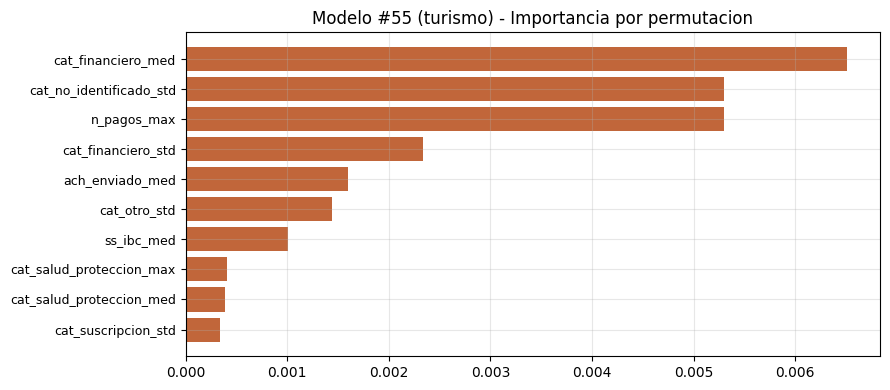

cat_financiero_med         0.01
cat_no_identificado_std    0.01
n_pagos_max                0.01
cat_financiero_std         0.00
ach_enviado_med            0.00
cat_otro_std               0.00
ss_ibc_med                 0.00
cat_salud_proteccion_max   0.00
cat_salud_proteccion_med   0.00
cat_suscripcion_std        0.00
dtype: float64

In [22]:
importancia_turismo = permutation_importance(resultado_turismo["modelo"], resultado_turismo["Xte"],
                                             resultado_turismo["yte"], n_repeats=5,
                                             random_state=SEMILLA, n_jobs=1)
top_turismo = (pd.Series(importancia_turismo.importances_mean, index=resultado_turismo["columnas"])
              .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(len(top_turismo)), top_turismo.values[::-1], color="#c1663a")
ax.set_yticks(range(len(top_turismo))); ax.set_yticklabels(top_turismo.index[::-1], fontsize=9)
ax.set_title("Modelo #55 (turismo) - Importancia por permutacion")
plt.tight_layout(); plt.show()
top_turismo.round(4)

**Que predice mejor la propension a viajar.** El gasto en categoria financiera (nivel de
endeudamiento y su variabilidad) encabeza la lista, seguido por el maximo numero de pagos en un mes y el
monto enviado por ACH. La lectura de negocio: la propension a viajar se asocia mas con **tener capacidad
financiera disponible y un patron de gasto activo**, que con cualquier senal directa de haber viajado
antes -coherente con que el modelo funcione bien incluso en adoptantes nuevos-.

## 7. Tabla consolidada de salida

In [23]:
salida = pd.DataFrame(index=rfm.index)
salida["segmento_rfm"] = rfm["segmento"]
salida["recencia_meses"] = rfm["recencia_meses"]
salida["frecuencia_pagos"] = rfm["frecuencia"]
salida["gasto_total_ventana"] = rfm["monetario"].round(0)
salida = salida.join(wallet[["share_of_wallet", "diversificacion"]], how="left")

for nombre_col, resultado, columna_cat in [
    ("prob_educacion", resultado_educacion, "cat_educacion"),
    ("prob_turismo", resultado_turismo, "cat_turismo"),
    ("prob_suscripcion", resultado_suscripcion, "cat_suscripcion"),
]:
    F_completo = construir_features(
        pse_pm[(pse_pm.per >= TRAIN_INI) & (pse_pm.per <= TRAIN_FIN)],
        ach_pm[(ach_pm.per >= TRAIN_INI) & (ach_pm.per <= TRAIN_FIN)],
        ss_pm[(ss_pm.per >= TRAIN_INI) & (ss_pm.per <= TRAIN_FIN)],
        excluir_categoria=columna_cat)
    universo_valido = F_completo.index[F_completo.pse_meses >= 2]
    probs = resultado["modelo"].predict_proba(F_completo.loc[universo_valido].values)[:, 1]
    salida.loc[universo_valido, nombre_col] = probs

salida.to_parquet("salida_caso04_comportamientos_consumo.parquet")
print(f"Tabla de salida: {salida.shape[0]:,} personas x {salida.shape[1]} campos\n")
salida.head(8)

Tabla de salida: 32,934 personas x 9 campos



,segmento_rfm,recencia_meses,frecuencia_pagos,gasto_total_ventana,share_of_wallet,diversificacion,prob_educacion,prob_turismo,prob_suscripcion
cli,,,,,,,,,
************ -|23318527****,Perdidos,2,4,"469,115.00",1.30,-0.00,NaN,NaN,NaN
************ .|23202463****,En riesgo (alto valor),0,48,"8,186,935.00",5.00,0.19,0.55,0.32,0.71
************ .|23202464****,Perdidos,6,1,"1,478,637.00",5.00,-0.00,NaN,NaN,NaN
************ .|23291533****,En riesgo (alto valor),1,20,"4,023,014.00",5.00,0.09,0.51,0.48,0.54
************ .|23299215****,Hibernando,0,10,"7,068,466.00",5.00,0.14,0.51,0.36,0.06
************ .|23351581****,Hibernando,1,10,"726,254.00",0.87,0.45,0.62,0.47,0.73
************ ABRIL AVILA|23436170****,En riesgo (alto valor),0,54,"4,265,596.00",0.33,0.29,0.40,0.29,0.61
************ ABRIL SERRANO|23224463****,En riesgo (alto valor),0,55,"2,854,617.00",0.59,0.64,0.48,0.23,0.88


## 8. Resumen de desempeno y hallazgos

| Modelo | Tipo | Metrica principal | Resultado | Estado |
|---|---|---|---|---|
| **#15** Segmentacion RFM | Clustering / reglas | Coincidencia con KMeans no supervisado | Alta coincidencia en los extremos | Operable |
| **#16** Share of wallet | Score / indice | Coherencia con hallazgos del Caso 02 | Share mediano 0,51, financiero 26,5% del ingreso | Operable, cota inferior |
| **#17** Propension (demo educacion) | Clasificacion temporal | AUC / lift decil superior | 0,646 / 2,0x | Operable para priorizar |
| **#55** Propension a turismo | Clasificacion temporal | AUC / AUC en nuevos adoptantes | 0,708 / 0,70 | El mas solido: agrega valor real |
| **#57** Propension a suscripciones | Clasificacion temporal | AUC / AUC en nuevos adoptantes | 0,816 / 0,529 | Util solo para retencion, no adquisicion |

**Hallazgos centrales del caso**

1. La taxonomia de comercios por palabras clave clasifica el 78% del gasto en categorias con sentido de
   negocio, con dos anadidos especificos para este caso: turismo (857 personas identificadas) y un
   patron de comportamiento tipo suscripcion (5.092 personas), este ultimo dominado por telecomunicaciones
   mas que por streaming, debido a las limitaciones de ofuscamiento ya explicadas.
2. La segmentacion RFM identifica un nucleo de 6.279 "Campeones" (gasto mediano ~9 millones) y 1.021
   personas de "alto valor en riesgo" que representan la mayor urgencia comercial de retencion.
3. El share of wallet mediano es 0,51 y el gasto financiero absorbe una mediana de 26,5% del ingreso
   observado -coherente con el hallazgo del Caso 02 sobre la carga de deuda de la poblacion-.
4. De los tres modelos de propension, **turismo es el unico que demuestra capacidad real de identificar
   candidatos nuevos** (AUC de 0,70 incluso sin historia previa en la categoria). El de suscripciones,
   pese a tener el AUC mas alto en general, resulta ser casi enteramente un modelo de persistencia.

## 9. Limitaciones, supuestos y siguientes pasos

### 9.1 Supuestos que condicionan los resultados

1. **La categoria de "suscripciones digitales" es un proxy de comportamiento, no de marca.** No se pudo
   verificar que los pagos detectados correspondan efectivamente a Netflix, Spotify u otro servicio de
   streaming; la evidencia muestra que el patron esta dominado por telecomunicaciones y servicios
   basicos. El nombre se mantiene por ser el que usa el catalogo, pero el contenido real es mas amplio.
2. **La segmentacion RFM usa solo el canal PSE.** No incorpora el gasto que la persona pueda hacer en
   efectivo o por otros medios no visibles en estos datos, por lo que subestima el nivel real de
   actividad de consumo de cualquier persona.
3. **El ingreso proxy del share of wallet hereda las limitaciones ya documentadas en el Caso 02**: para
   dependientes formales, el ACH solo observa el 22% de su ingreso real, lo que infla artificialmente el
   share of wallet calculado para ese segmento.
4. **Los modelos de propension usan un universo minimo de 2 meses de actividad en el periodo de
   entrenamiento.** Personas con solo 1 mes de historia quedan fuera de la evaluacion por falta de senal
   suficiente.

### 9.2 Limitaciones heredadas de los datos

Las mismas que en el Caso 02: el archivo de pagos digitales esta truncado en el limite de Excel
(1.048.574 filas), Transfiya se degrada desde octubre de 2025 (por eso se trabaja solo hasta septiembre),
y el ofuscamiento de nombres de comercio impide clasificar con certeza el 22,6% del gasto observado.

### 9.3 Siguientes pasos, en orden de impacto

1. **Conseguir una fuente de codigos MCC (Merchant Category Code)** para reemplazar la clasificacion
   por palabras clave, especialmente para separar streaming/software de telecomunicaciones dentro del
   patron de "suscripcion".
2. **Extender la ventana de evaluacion temporal** una vez se resuelva el quiebre de Transfiya, para
   confirmar si el modelo de turismo mantiene su desempeno en una ventana de prediccion mas larga (por
   ejemplo, propension a 6 meses en lugar de 3).
3. **Cruzar el segmento "Campeones" y "En riesgo - alto valor" de la RFM con el score de capacidad de
   ahorro del Caso 02 (#41)**, para priorizar campanas de retencion sobre quienes ademas tienen
   capacidad de pago confirmada.
4. **Backtesting del modelo de turismo con una campana piloto real**, para confirmar en produccion el
   lift de 2,75x observado en el quintil superior.

### 9.4 Nota sobre reproducibilidad

Todos los modelos usan `random_state = 42`. Los objetos entrenados quedan en memoria y pueden
serializarse con `joblib`. La tabla de salida se guarda en
`salida_caso04_comportamientos_consumo.parquet`.